In [3]:
%cd ../..

from hedging.envs import HedgeCallHeston
from experiments.utils.ppo_mlp_actor import create_ppo_mlp_actor
from experiments.utils.training_loop import action_training
from experiments.utils.testing import test_model
from experiments.utils.sim_config import (
    load_heston_data,
    EnvConfig,
    PPOConfig,
    TrainingConfig
)

import numpy as np
import torch

if not hasattr(torch.Tensor, "_orig_numpy"):
    torch.Tensor._orig_numpy = torch.Tensor.numpy

    def safe_numpy(self, *args, **kwargs):
        # transparently move tensor to CPU before numpy() if it's on GPU
        if self.is_cuda:
            return self.detach().cpu().numpy()
        return self._orig_numpy(*args, **kwargs)

    torch.Tensor.numpy = safe_numpy

# --- Env Parameters ---
params, S0, K, v0 = load_heston_data()
env_cfg = EnvConfig()
ppo_cfg = PPOConfig()
train_cfg = TrainingConfig()

r = env_cfg.r
maturity = env_cfg.maturity
trap = env_cfg.trap
num_paths = env_cfg.num_paths
num_steps = env_cfg.num_steps
history_len = env_cfg.history_len
input_dim = 11
hidden_size = train_cfg.hidden_size
action_dim = 1
transaction_cost = env_cfg.transaction_cost
transaction_fee_rate = env_cfg.transaction_fee_rate


base_env = HedgeCallHeston(
    S0=S0, K = K, r=r, v0=v0, theta=params["theta"], rho=params["rho"],
    kappa=params["kappa"], xi=params["sigma"], maturity=maturity,
    num_steps=num_steps, num_paths=10, history_len=history_len, 
    transaction_cost=transaction_cost, transaction_fee_rate=transaction_fee_rate
)

/Users/manu13/Desktop/PHD/DeepHedging/deep_hedging_v0


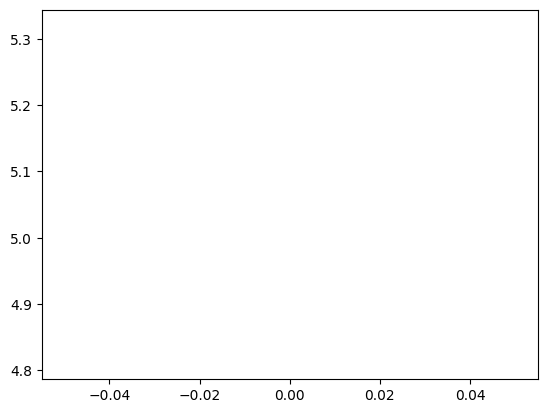

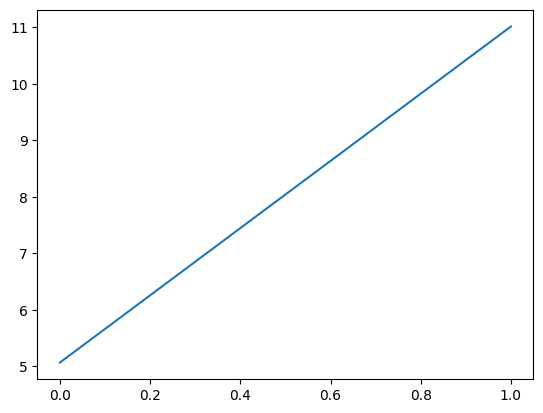

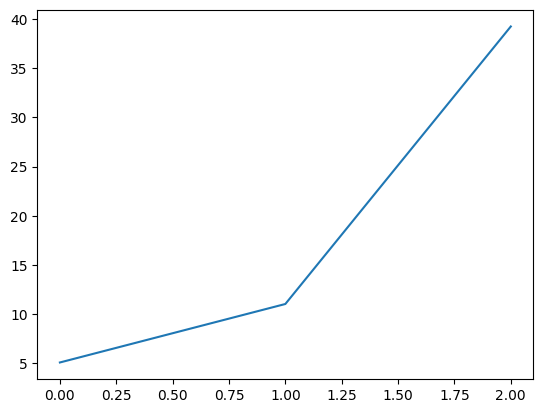

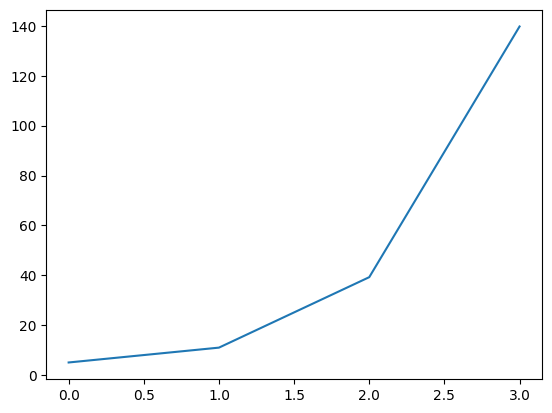

KeyboardInterrupt: 

In [5]:
paths = [1,2,3,4,5,6,7]
res = []
import time
import matplotlib.pyplot as plt

for p in paths:
    start = time.time()
    base_env = HedgeCallHeston(
    S0=S0, K = K, r=r, v0=v0, theta=params["theta"], rho=params["rho"],
    kappa=params["kappa"], xi=params["sigma"], maturity=maturity,
    num_steps=num_steps, num_paths=p, history_len=history_len, 
    transaction_cost=transaction_cost, transaction_fee_rate=transaction_fee_rate)
    base_env.reset()
    res.append(time.time() - start)
    plt.plot(res)
    plt.show()
